Imports

In [63]:
# ============================================================
# Window-to-Wall Ratio Segmentation Framework
# Intelligent Computing Version
# ============================================================

import os
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

Environment Configuration

In [64]:
# ============================================================
# Environment Configuration
# ============================================================

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

GPU Configuration

In [65]:
# ============================================================
# GPU Configuration
# ============================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("TensorFlow :", tf.__version__)
print("GPU :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.20.0
GPU : []


Mixed Precision

In [66]:
# ============================================================
# Mixed Precision
# ============================================================

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

print("Mixed Precision :", mixed_precision.global_policy())

Mixed Precision : <DTypePolicy "mixed_float16">


Mount Google Drive

In [67]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Copy Dataset to Local SSD

In [68]:
# ============================================================
# Copy Dataset
# ============================================================

!cp "/content/drive/MyDrive/WWR_Seg_Model/data.zip" /content/

!unzip -oq /content/data.zip -d /content/

Configuration

In [69]:
@dataclass
class Config:

    IMAGE_SIZE = 512

    IMAGE_CHANNELS = 3

    MASK_CHANNELS = 1

    NUM_CLASSES = 4

    BATCH_SIZE = 32

    EPOCHS = 150

    LEARNING_RATE = 1e-4

    WEIGHT_DECAY = 1e-5

    BUFFER_SIZE = 1000

    SEED = 42

    TRAIN_RATIO = 0.90

    VAL_RATIO = 0.10

    NUM_WORKERS = AUTOTUNE

Segmentation Classes

In [70]:
# ============================================================
# Segmentation Classes
# ============================================================

CLASS_INFO = {
    0: {"name": "Roof",   "gray": 72},
    1: {"name": "Window", "gray": 128},
    2: {"name": "Wall",   "gray": 220},
    3: {"name": "Other",  "gray": 255},
}

CLASS_NAMES = [v["name"] for v in CLASS_INFO.values()]

GRAY_VALUES = [v["gray"] for v in CLASS_INFO.values()]

GRAY_TO_CLASS = {
    72: 0,
    128: 1,
    220: 2,
    255: 3
}

CLASS_TO_GRAY = {
    0: 72,
    1: 128,
    2: 220,
    3: 255
}

print("="*50)

print("Segmentation Classes")

print("="*50)

for idx in CLASS_INFO:

    print(
        f"{idx} -> "
        f"{CLASS_INFO[idx]['name']} "
        f"(Gray={CLASS_INFO[idx]['gray']})"
    )

Segmentation Classes
0 -> Roof (Gray=72)
1 -> Window (Gray=128)
2 -> Wall (Gray=220)
3 -> Other (Gray=255)


Project Paths

In [71]:
# ============================================================
# Project Paths
# ============================================================

# ---------- Local SSD ----------

LOCAL_ROOT = Path("/content")

IMAGE_DIR = LOCAL_ROOT / "images"

MASK_DIR = LOCAL_ROOT / "masks"

# ---------- Google Drive ----------

DRIVE_ROOT = Path("/content/drive/MyDrive/WWR_Seg_Model")

MODEL_DIR = DRIVE_ROOT / "models"

CHECKPOINT_DIR = DRIVE_ROOT / "checkpoints"

LOG_DIR = DRIVE_ROOT / "logs"

RESULT_DIR = DRIVE_ROOT / "results"

for folder in [

    MODEL_DIR,

    CHECKPOINT_DIR,

    LOG_DIR,

    RESULT_DIR

]:

    folder.mkdir(parents=True, exist_ok=True)

print("Local Dataset :", LOCAL_ROOT)

print("Project Root :", DRIVE_ROOT)

Local Dataset : /content
Project Root : /content/drive/MyDrive/WWR_Seg_Model


Verify Dataset

In [72]:
# ============================================================
# Verify Dataset
# ============================================================

print("=" * 60)
print("Verifying Dataset...")
print("=" * 60)

# ------------------------------------------------------------
# Check folders
# ------------------------------------------------------------

assert IMAGE_DIR.exists(), f"Image folder not found:\n{IMAGE_DIR}"
assert MASK_DIR.exists(), f"Mask folder not found:\n{MASK_DIR}"

# ------------------------------------------------------------
# Read file names
# ------------------------------------------------------------

image_files = sorted(IMAGE_DIR.glob("*.png"))
mask_files  = sorted(MASK_DIR.glob("*.png"))

assert len(image_files) > 0, "No images found."
assert len(mask_files) > 0, "No masks found."

assert len(image_files) == len(mask_files), \
    "Number of images and masks are different."

# ------------------------------------------------------------
# Check file names
# ------------------------------------------------------------

for img_path, mask_path in zip(image_files, mask_files):

    image_id = img_path.stem.replace("_texture", "")
    mask_id  = mask_path.stem.replace("_mask", "")

    assert image_id == mask_id, (
        f"Image/Mask mismatch:\n"
        f"{img_path.name}\n"
        f"{mask_path.name}"
    )

# ------------------------------------------------------------
# Check one sample image
# ------------------------------------------------------------

sample_image = tf.io.decode_png(
    tf.io.read_file(str(image_files[0])),
    channels=Config.IMAGE_CHANNELS
)

sample_mask = tf.io.decode_png(
    tf.io.read_file(str(mask_files[0])),
    channels=Config.MASK_CHANNELS
)

assert sample_image.shape[-1] == 3, \
    "Images must be RGB."

assert sample_mask.shape[-1] == 1, \
    "Masks must be Grayscale."

# ------------------------------------------------------------
# Check grayscale labels
# ------------------------------------------------------------

valid_values = {
    info["gray"]
    for info in CLASS_INFO.values()
}

for mask_path in mask_files:

    mask = tf.io.decode_png(
        tf.io.read_file(str(mask_path)),
        channels=1
    )

    values = np.unique(mask.numpy())

    invalid = set(values) - valid_values

    assert len(invalid) == 0, \
        f"Invalid grayscale values in {mask_path.name}: {invalid}"

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print(f"Images            : {len(image_files)}")
print(f"Masks             : {len(mask_files)}")
print(f"Image Channels    : {sample_image.shape[-1]}")
print(f"Mask Channels     : {sample_mask.shape[-1]}")
print(f"Gray Values       : {GRAY_VALUES}")

print("\nDataset verification completed successfully.")
del sample_image
del sample_mask
print("=" * 60)

Verifying Dataset...
Images            : 1000
Masks             : 1000
Image Channels    : 3
Mask Channels     : 1
Gray Values       : [72, 128, 220, 255]

Dataset verification completed successfully.


Project Summary

In [73]:
# ============================================================
# Project Summary
# ============================================================

print("="*60)

print("Window Segmentation Framework")

print("="*60)

print("Image Size :", Config.IMAGE_SIZE)

print("Batch Size :", Config.BATCH_SIZE)

print("Epochs     :", Config.EPOCHS)

print("Classes    :", Config.NUM_CLASSES)

print("Dataset    :", len(image_files))

print("="*60)

Window Segmentation Framework
Image Size : 512
Batch Size : 32
Epochs     : 150
Classes    : 4
Dataset    : 1000


Train / Validation Split

In [74]:
# ============================================================
# Train / Validation Split
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Create image-mask pairs
# ------------------------------------------------------------

dataset_pairs = list(zip(image_files, mask_files))

# ------------------------------------------------------------
# Train / Validation split
# ------------------------------------------------------------

train_pairs, val_pairs = train_test_split(
    dataset_pairs,
    train_size=Config.TRAIN_RATIO,
    random_state=Config.SEED,
    shuffle=True
)

print("=" * 60)
print("Dataset Split")
print("=" * 60)

print(f"Training Images    : {len(train_pairs)}")
print(f"Validation Images  : {len(val_pairs)}")

print("=" * 60)

Dataset Split
Training Images    : 900
Validation Images  : 100


Image & Mask Loading Functions

In [75]:
# ============================================================
# Image & Mask Loading Functions
# ============================================================

def load_image(image_path):
    """
    Load an RGB image and normalize to [0, 1].
    """

    image = tf.io.read_file(image_path)

    image = tf.io.decode_png(
        image,
        channels=Config.IMAGE_CHANNELS
    )

    image = tf.image.resize(
        image,
        (Config.IMAGE_SIZE, Config.IMAGE_SIZE),
        method="bilinear"
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image


def load_mask(mask_path):
    """
    Load a grayscale segmentation mask.
    """

    mask = tf.io.read_file(mask_path)

    mask = tf.io.decode_png(
        mask,
        channels=Config.MASK_CHANNELS
    )

    mask = tf.image.resize(
        mask,
        (Config.IMAGE_SIZE, Config.IMAGE_SIZE),
        method="nearest"
    )

    mask = tf.cast(mask, tf.uint8)

    return mask

Convert Grayscale Mask to Class IDs

In [76]:
# ============================================================
# Convert Grayscale Mask to Class IDs
# ============================================================

# Lookup Table
LUT = np.full(256, 255, dtype=np.uint8)

for class_id, info in CLASS_INFO.items():
    LUT[info["gray"]] = class_id

LUT = tf.constant(LUT)


def convert_mask(mask):
    """
    Convert grayscale mask values to class IDs.

    Gray values:
        72  -> 0 (Roof)
        128 -> 1 (Window)
        220 -> 2 (Wall)
        255 -> 3 (Other)
    """

    mask = tf.squeeze(mask, axis=-1)

    mask = tf.gather(LUT, tf.cast(mask, tf.int32))

    mask = tf.expand_dims(mask, axis=-1)

    return tf.cast(mask, tf.uint8)

Create Dataset Parser

In [77]:
# ============================================================
# Dataset Parser
# ============================================================

def load_sample(image_path, mask_path):
    """
    Load one image-mask pair.
    """

    image = load_image(image_path)

    mask = load_mask(mask_path)

    mask = convert_mask(mask)

    return image, mask

Create tf.data Dataset

In [78]:
# ============================================================
# tf.data Dataset
# ============================================================

def create_dataset(pairs):

    image_paths = [str(img) for img, _ in pairs]
    mask_paths  = [str(mask) for _, mask in pairs]

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, mask_paths)
    )

    dataset = dataset.map(
        load_sample,
        num_parallel_calls=AUTOTUNE
    )

    return dataset

Create Train & Validation Dataset

In [79]:
# ============================================================
# Create Train / Validation Dataset
# ============================================================

train_dataset = create_dataset(train_pairs)
val_dataset   = create_dataset(val_pairs)

print("Train :", len(train_pairs))
print("Validation :", len(val_pairs))

Train : 900
Validation : 100


Data Augmentation

In [80]:
# ============================================================
# Data Augmentation
# ============================================================

def augment_sample(image, mask):

    seed = tf.random.uniform(
        shape=(2,),
        maxval=100000,
        dtype=tf.int32
    )

    # ---------- Geometric ----------
    image = tf.image.stateless_random_flip_left_right(image, seed)
    mask  = tf.image.stateless_random_flip_left_right(mask, seed)

    image = tf.image.stateless_random_flip_up_down(image, seed)
    mask  = tf.image.stateless_random_flip_up_down(mask, seed)

    # ---------- Photometric ----------
    image = tf.image.random_brightness(image, 0.15)

    image = tf.image.random_contrast(
        image,
        0.90,
        1.10
    )

    image = tf.image.random_saturation(
        image,
        0.90,
        1.10
    )

    return image, mask

Create Dataset

In [81]:
# ============================================================
# tf.data Dataset
# ============================================================

def create_dataset(
    pairs,
    training=False
):

    image_paths = [str(img) for img, _ in pairs]

    mask_paths = [str(mask) for _, mask in pairs]

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, mask_paths)
    )

    dataset = dataset.map(
        load_sample,
        num_parallel_calls=AUTOTUNE
    )
    dataset = dataset.cache()
    if training:

        dataset = dataset.shuffle(
            Config.BUFFER_SIZE,
            seed=Config.SEED,
            reshuffle_each_iteration=True
        )

        dataset = dataset.map(
            augment_sample,
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.batch(Config.BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

Create Train / Validation Dataset

In [82]:
# ============================================================
# Create Train / Validation Dataset
# ============================================================

train_dataset = create_dataset(
    train_pairs,
    training=True
)

val_dataset = create_dataset(
    val_pairs,
    training=False
)

print("=" * 60)
print("Dataset Pipeline Ready")
print("=" * 60)
print(f"Train Batches      : {len(train_dataset)}")
print(f"Validation Batches : {len(val_dataset)}")
print("=" * 60)

Dataset Pipeline Ready
Train Batches      : 29
Validation Batches : 4


Visualize Dataset Samples

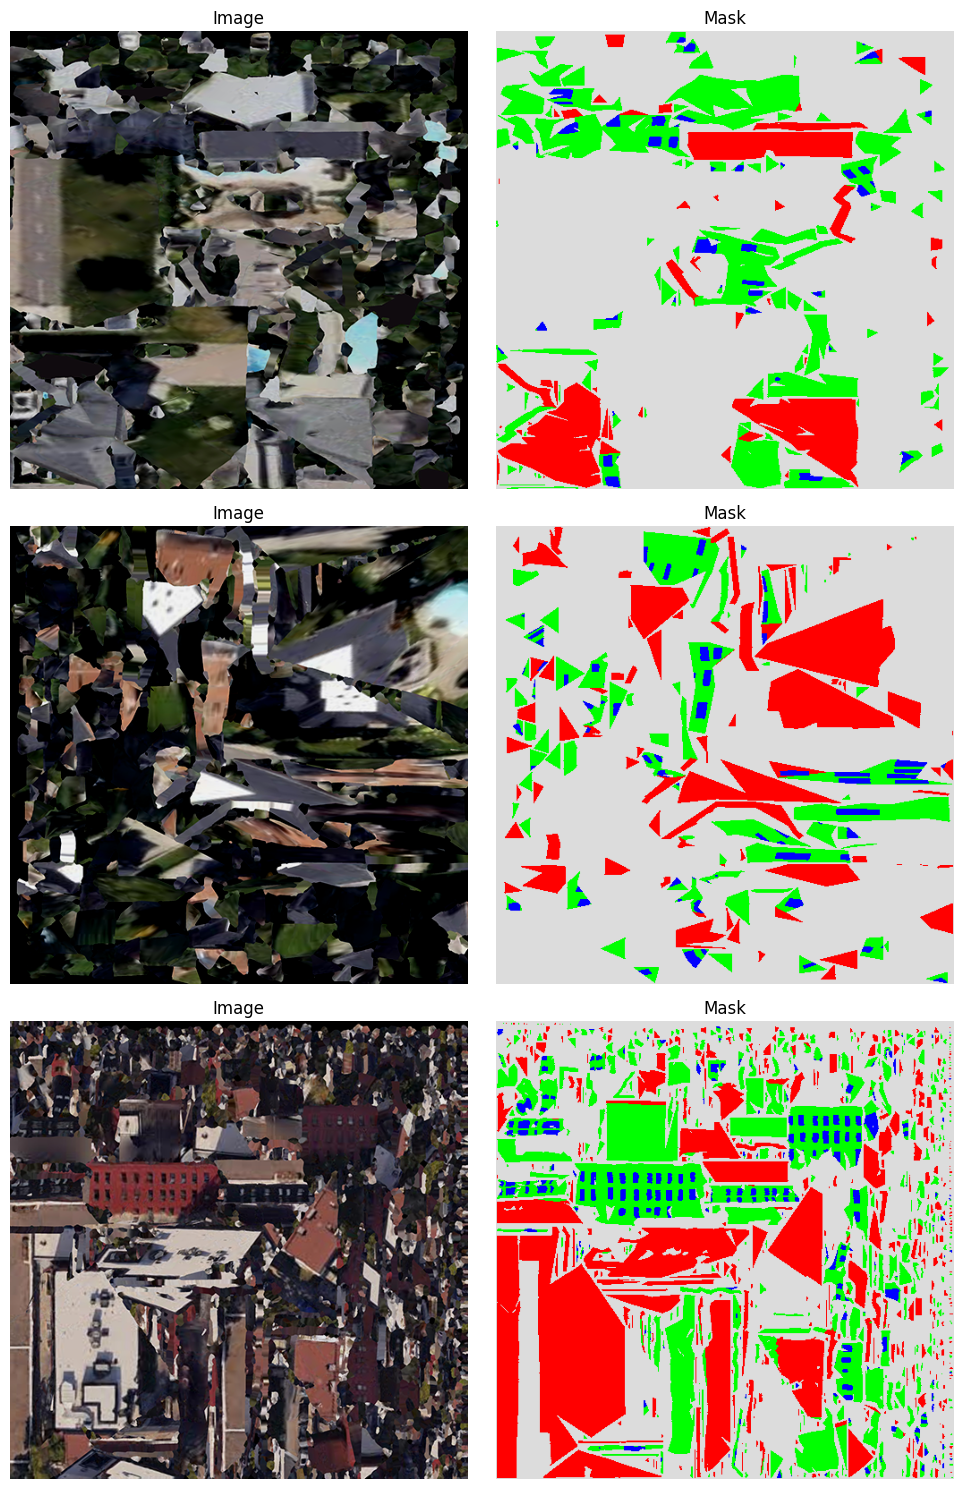

In [83]:
# ============================================================
# Visualize Dataset Samples
# ============================================================

CLASS_COLORS = np.array([
    [255,   0,   0],   # Roof   - Red
    [  0,   0, 255],   # Window - Blue
    [  0, 255,   0],   # Wall   - Green
    [220, 220, 220],   # Other  - Light Gray
], dtype=np.uint8)


def decode_mask(mask):

    mask = tf.squeeze(mask).numpy()

    return CLASS_COLORS[mask]


images, masks = next(iter(train_dataset))

fig, axes = plt.subplots(3, 2, figsize=(10, 15))

for i in range(3):

    axes[i,0].imshow(images[i])

    axes[i,0].set_title("Image")

    axes[i,0].axis("off")


    axes[i,1].imshow(decode_mask(masks[i]))

    axes[i,1].set_title("Mask")

    axes[i,1].axis("off")

plt.tight_layout()

plt.show()

Dataset Statistics

In [84]:
# ============================================================
# Dataset Statistics
# ============================================================

print("=" * 60)

print("Dataset Summary")

print("=" * 60)

print(f"Training Images      : {len(train_pairs)}")

print(f"Validation Images    : {len(val_pairs)}")

print(f"Training Batches     : {len(train_dataset)}")

print(f"Validation Batches   : {len(val_dataset)}")

print(f"Image Size           : {Config.IMAGE_SIZE}")

print(f"Batch Size           : {Config.BATCH_SIZE}")

print(f"Number of Classes    : {Config.NUM_CLASSES}")

print("=" * 60)

Dataset Summary
Training Images      : 900
Validation Images    : 100
Training Batches     : 29
Validation Batches   : 4
Image Size           : 512
Batch Size           : 32
Number of Classes    : 4
